In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
data =load_diabetes()




In [12]:
ddf_data = pd.DataFrame(data.data,columns=data.feature_names)
ddf_data['Target'] = pd.DataFrame(data.target)
ddf_data.head(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0


In [ ]:
# age: Age of the patient (in years).
# sex: Patient’s sex (Male/Female).
# bmi: Body Mass Index (a calculated value based on height and weight).
# bp: Blood Pressure (in mmHg – a crucial factor in diabetes management).
# s1: S1 (Blood Sugar Level - measured during a test).
# s2: S2 (Blood Sugar Level - measured later in the day).
# s3: S3 (Blood Sugar Level - measured during a test).
# s4: S4 (Blood Sugar Level - measured during a test).
# s5: S5 (Blood Sugar Level - measured during a test).
# s6: S6 (Blood Sugar Level - measured during a test).

In [ ]:
#age vs Target - Assumption is that older people with 
features = [
    's1', 's2', 's3', 's4', 's5', 's6',
]

ddf_data['mean_s1_s6']=ddf_data[features].mean(axis=1)
ddf_data['median_s1_s6']=ddf_data[features].median(axis=1)
ddf_data['std_s1_s6']=ddf_data[features].std(axis=1)


ddf_data.head(2)



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target,mean_s1_s6,median_s1_s6,std_s1_s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,-0.020463,-0.026233,0.025510
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,-0.025538,-0.029328,0.057953


/var/folders/fq/kr6gv5l17pd4j572n0_n3f2c0000gn/T/ipykernel_89640/960911070.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


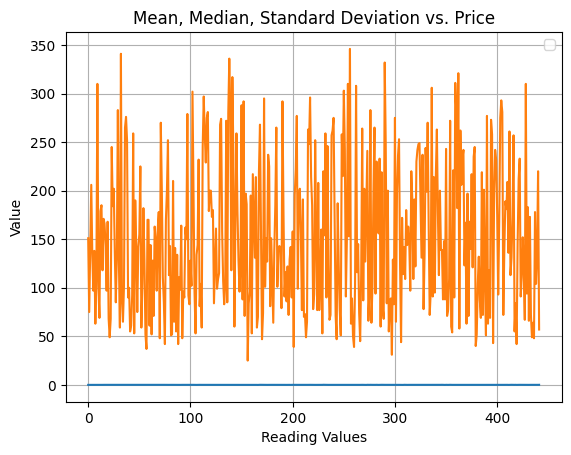

In [31]:
plt.Figure(figsize=(12, 6))
plt.plot(ddf_data[['mean_s1_s6', 'Target']].values)
plt.xlabel('Reading Values')
plt.ylabel('Value')
plt.title('Mean, Median, Standard Deviation vs. Price')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# lets say usally you do 2000 tx day <--- cust ABC
# sudden at mid night ==> 10000 tx in 1 day <--- cust ABC
# sudden spike in tx volume ==> anomaly / fraud / attack

# fraud_detection_model.predict()
# we will pass customer info. -> given trx is fraud or not
# classification model
# output ==> fraud / not fraud

In [34]:
# load the data
data = pd.read_csv('seed.csv')
data.head(2)

# here 
# 0 indicates normal trx
# 1 indicates fraud trx

# do you have imblance data or not
data['is_fraud'].value_counts(normalize=True)
# oversampling or undersampling
# SMOTE??

is_fraud
0    0.98218
1    0.01782
Name: proportion, dtype: float64

### 01. Data Analysis

In [35]:
# list the columns
data.columns.tolist()


['txn_id',
 'timestamp',
 'txn_type',
 'channel',
 'amount',
 'status',
 'payer_upi',
 'payee_upi',
 'payer_device_id',
 'payee_device_id',
 'payer_city',
 'payee_city',
 'is_fraud',
 'payer_lat',
 'payer_lon',
 'payee_lat',
 'payee_lon']

In [36]:
# problem statement
# CHECK IF GIVEN TRASANCTION is fraudulent or not
# input give to you
# 'txn_id',
#  'timestamp',
#  'txn_type',
#  'channel',
#  'amount',
#  'status',
#  'payer_upi',
#  'payee_upi',
#  'payer_device_id',
#  'payee_device_id',
#  'payer_city',
#  'payee_city',
#  'is_fraud',
#  'payer_lat',
#  'payer_lon',
#  'payee_lat',
#  'payee_lon']


# define each column
# 'txn_id' : unique transaction identifier
# 'timestamp' : date and time of the transaction
# 'txn_type' : type of transaction (e.g., payment, transfer)
# 'channel' : channel through which the transaction was made (e.g., mobile, web
# 'amount' : amount of money involved in the transaction
# 'status' : status of the transaction (e.g., completed, pending, failed)
# 'payer_upi' : unique identifier for the payer's UPI account
# 'payee_upi' : unique identifier for the payee's UPI account
# 'payer_device_id' : unique identifier for the payer's device
# 'payee_device_id' : unique identifier for the payee's device
# 'payer_city' : city of the payer
# 'payee_city' : city of the payee
# 'is_fraud' : target variable indicating whether the transaction is fraudulent (1) or
# not (0)
# 'payer_lat' : latitude of the payer's location
# 'payer_lon' : longitude of the payer's location
# 'payee_lat' : latitude of the payee's location
# 'payee_lon' : longitude of the payee's location

# feature engineering ideas
# 1. Time-based features: Extract features like hour of the day, day of the week,
# and month from the timestamp to capture temporal patterns in fraudulent
# transactions.
# 2. Transaction amount features: Create features such as log-transformed amount,
# amount bins, or amount deviation from the user's average transaction amount to
# identify unusual spending behavior.
# 3. Geographical features: Calculate the distance between payer and payee using
# their latitude and longitude. This can help identify transactions that occur
# over unusually long distances.
# 4. Device features: Count the number of unique devices used by the payer and
# payee. Multiple devices may indicate suspicious activity. 
# 5. Frequency features: Calculate the number of transactions made by the payer
# and payee within a specific time window (e.g., last hour, last day) to identify
# rapid transaction patterns.
# 6. Channel features: Create binary features for each transaction channel to
# capture channel-specific fraud patterns.
# 7. Status features: Create binary features for each transaction status to
# capture status-specific fraud patterns.

# which feature can be more important
# 1. amount
# 2. time of transaction
# 3. location (payer_city, payee_city, payer_lat, payer_lon, payee_lat, payee_lon)
# 4. device_id (payer_device_id, payee_device_id)
# 5. channel
# 6. txn_type


### Feature engineering

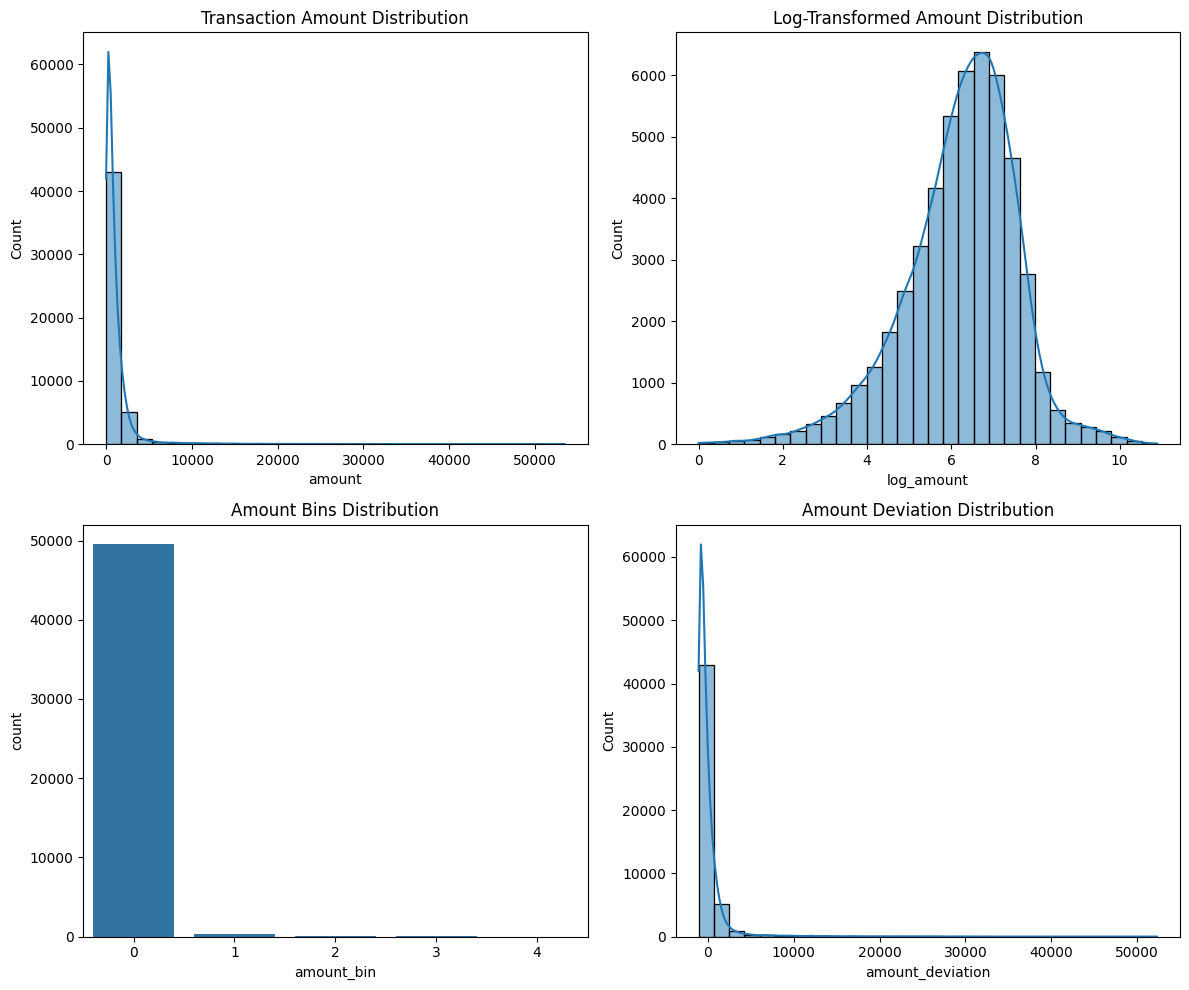

In [37]:
#1. Time-based features: Extract features like hour of the day, day of the week,
# and month from the timestamp to capture temporal patterns in fraudulent
# transactions.
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month

# 2. Transaction amount features: Create features such as log-transformed amount,
# amount bins, or amount deviation from the user's average transaction amount to
# identify unusual spending behavior.
data['log_amount'] = np.log1p(data['amount'])
data['amount_bin'] = pd.cut(data['amount'], bins=5, labels=False)
data['amount_deviation'] = data['amount'] - data['amount'].mean()   

# lets plot amount , log_amount , amount_bin , amount_deviation
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data['amount'], bins=30, ax=axs[0, 0], kde=True).set_title('Transaction Amount Distribution')
sns.histplot(data['log_amount'], bins=30, ax=axs[0, 1], kde=True).set_title('Log-Transformed Amount Distribution')
sns.countplot(x='amount_bin', data=data, ax=axs[1, 0]).set_title('Amount Bins Distribution')
sns.histplot(data['amount_deviation'], bins=30, ax=axs[1, 1], kde=True).set_title('Amount Deviation Distribution')
plt.tight_layout()
plt.show()

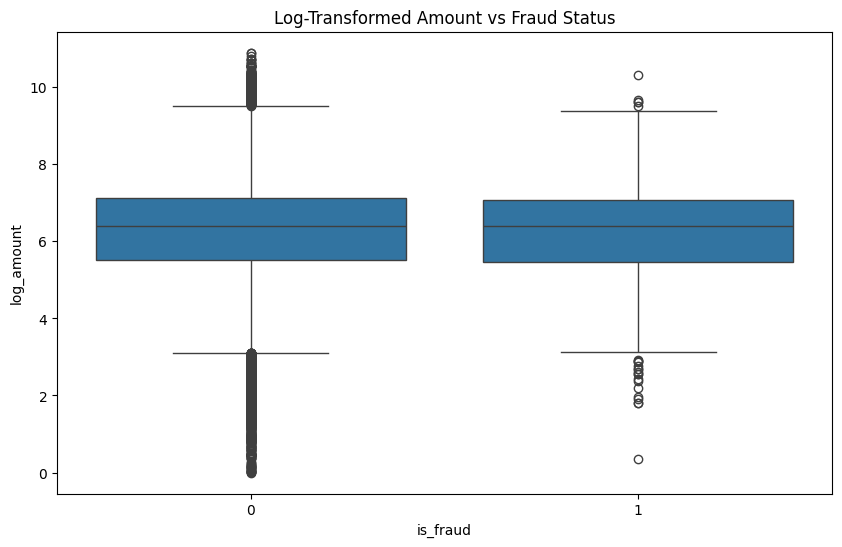

In [38]:
# lets analyze amount vs is_fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='log_amount', data=data)
plt.title('Log-Transformed Amount vs Fraud Status')
plt.show()

In [39]:
# 3. Geographical features: Calculate the distance between payer and payee using
# their latitude and longitude. This can help identify transactions that occur
# over unusually long distances.
from geopy.distance import geodesic 
def calculate_distance(row):
    payer_coords = (row['payer_lat'], row['payer_lon'])
    payee_coords = (row['payee_lat'], row['payee_lon'])
    return geodesic(payer_coords, payee_coords).km

data['distance'] = data.apply(calculate_distance, axis=1)
data[['payer_lat', 'payer_lon', 'payee_lat', 'payee_lon', 'distance']].head()

,payer_lat,payer_lon,payee_lat,payee_lon,distance
0,13.010152,80.149609,19.268977,72.943460,1035.853285
1,26.902490,75.647761,18.641976,73.826701,933.657547
2,13.037115,80.321958,22.524512,88.253898,1344.547411
3,17.575641,78.349395,28.725076,77.362832,1238.890107
4,12.930532,80.142929,12.914867,77.569873,279.227694


In [40]:
# 4. Device features: Count the number of unique devices used by the payer and
# payee. Multiple devices may indicate suspicious activity.
data['payer_device_count'] = data.groupby('payer_upi')['payer_device_id'].transform('nunique')
data['payee_device_count'] = data.groupby('payee_upi')['payee_device_id'].transform('nunique')
data[['payer_upi', 'payer_device_id', 'payer_device_count', 'payee_upi', 'payee_device_id', 'payee_device_count']].head()

,payer_upi,payer_device_id,payer_device_count,payee_upi,payee_device_id,payee_device_count
0,wriddhishc@oksbi,dev_67167599,6,turvisarka@okaxis,dev_57381303,4
1,jhalakchad@okhdfcbank,dev_40445397,4,aarushkeer@okaxis,dev_77500837,4
2,barkhamaha@oksbi,dev_7660973,4,oshanair@okhdfcbank,dev_14609780,3
3,aayushvohr@okicici,dev_3978629,2,bhavnalank@okicici,dev_21151283,1
4,paninisesh@oksbi,dev_12206949,3,chaitanyav@okicici,dev_86057425,4


In [42]:
# 5. Frequency features: Calculate the number of transactions made by the payer
# and payee within a specific time window (e.g., last hour, last day) to identify
# rapid transaction patterns.
data = data.sort_values(by='timestamp')
data['payer_txn_last_hour'] = (
    data.groupby('payer_upi')['timestamp']
    .transform(lambda x: x.diff().dt.total_seconds().lt(3600).cumsum())
)
data['payee_txn_last_hour'] = (
    data.groupby('payee_upi')['timestamp']
    .transform(lambda x: x.diff().dt.total_seconds().lt(3600).cumsum())
)
data[['payer_upi', 'timestamp', 'payer_txn_last_hour', 'payee_upi', 'payee_txn_last_hour']].head()

,payer_upi,timestamp,payer_txn_last_hour,payee_upi,payee_txn_last_hour
14440,chasmumran@okhdfcbank,2025-01-01 00:00:00,0,vedhikabha@oksbi,0
10033,oeshikhare@okicici,2025-01-01 00:01:00,0,ekantasari@okicici,0
40411,unnikrishn@oksbi,2025-01-01 00:02:00,0,leelathama@okicici,0
27332,onipandya@okyesbank,2025-01-01 00:03:00,0,kalpitiyen@okaxis,0
630,amrutavirk@okyesbank,2025-01-01 00:04:00,0,atharvgosw@okhdfcbank,0


In [43]:
data.head(2)

,txn_id,timestamp,txn_type,channel,amount,status,payer_upi,payee_upi,payer_device_id,payee_device_id,...,day_of_week,month,log_amount,amount_bin,amount_deviation,distance,payer_device_count,payee_device_count,payer_txn_last_hour,payee_txn_last_hour
14440,UPI1000000,2025-01-01 00:00:00,P2M,QR,393.03,SUCCESS,chasmumran@okhdfcbank,vedhikabha@oksbi,dev_41018575,dev_35240220,...,2,1,5.976427,0,-702.64991,1033.955948,2,2,0,0
10033,UPI1000001,2025-01-01 00:01:00,AutoPay,Intent,666.01,PENDING,oeshikhare@okicici,ekantasari@okicici,dev_56593427,dev_7703178,...,2,1,6.502805,0,-429.66991,840.940244,5,4,0,0


In [44]:
# lets remove unwanted columns
data = data.drop(columns=['txn_id', 'timestamp', 'payer_upi', 'payee_upi',
                          'payer_device_id', 'payee_device_id', 'payer_city', 'payee_city',
                          'payer_lat', 'payer_lon', 'payee_lat', 'payee_lon'])
data.head(2)

,txn_type,channel,amount,status,is_fraud,hour,day_of_week,month,log_amount,amount_bin,amount_deviation,distance,payer_device_count,payee_device_count,payer_txn_last_hour,payee_txn_last_hour
14440,P2M,QR,393.03,SUCCESS,0,0,2,1,5.976427,0,-702.64991,1033.955948,2,2,0,0
10033,AutoPay,Intent,666.01,PENDING,0,0,2,1,6.502805,0,-429.66991,840.940244,5,4,0,0


In [49]:
# lisrt list out categorical and numerical features
categorical_features = ['txn_type', 'channel', 'status',  'hour', 'day_of_week', 'month']
numerical_features = ['amount', 'log_amount', 'amount_deviation', 'distance',
                      'payer_device_count', 'payee_device_count', 'payer_txn_last_hour', 'payee_txn_last_hour']

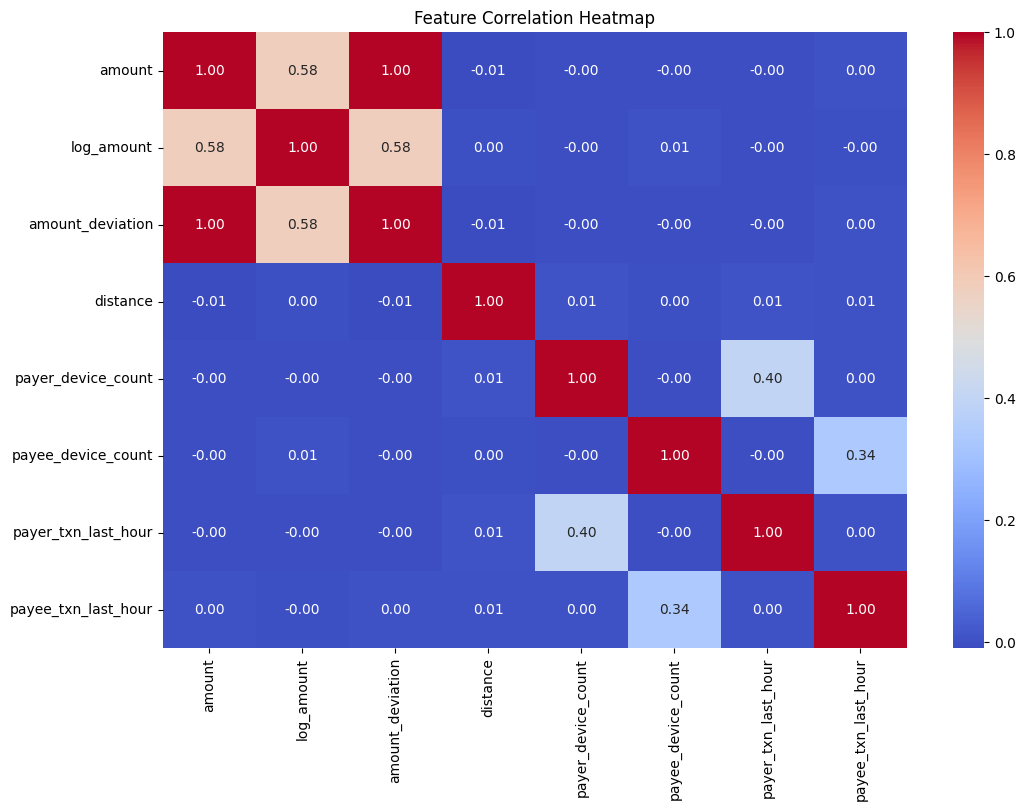

In [46]:
# lest plot the correlation heatmap
plt.figure(figsize=(12, 8))
corr = data[numerical_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()  

In [47]:
# lest remove multicollinear features
# based on correlation matrix, we can see that 'amount', 'log_amount' and 'amount_deviation' are
# highly correlated. We can drop 'amount', 'amount_deviation' and keep 'log_amount' for modeling.
data = data.drop(columns=['amount', 'amount_deviation','amount_bin'])
data.head(2)

,txn_type,channel,status,is_fraud,hour,day_of_week,month,log_amount,distance,payer_device_count,payee_device_count,payer_txn_last_hour,payee_txn_last_hour
14440,P2M,QR,SUCCESS,0,0,2,1,5.976427,1033.955948,2,2,0,0
10033,AutoPay,Intent,PENDING,0,0,2,1,6.502805,840.940244,5,4,0,0


In [50]:
# lets use get_dummies for categorical features
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)
data.head(2)

,is_fraud,log_amount,distance,payer_device_count,payee_device_count,payer_txn_last_hour,payee_txn_last_hour,txn_type_P2M,txn_type_P2P,channel_Intent,...,hour_21,hour_22,hour_23,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,month_2
14440,0,5.976427,1033.955948,2,2,0,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
10033,0,6.502805,840.940244,5,4,0,0,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [54]:
data.shape

(50000, 43)

In [51]:
# Performance Metrics in Machine Learning
# 1. Confusion Matrix
# 2. Precision, Recall, F1-Score

In [55]:
# lets start with basic model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,recall_score, precision_score, f1_score
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [56]:
# split train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# lets print the shape
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 42), (10000, 42), (40000,), (10000,))

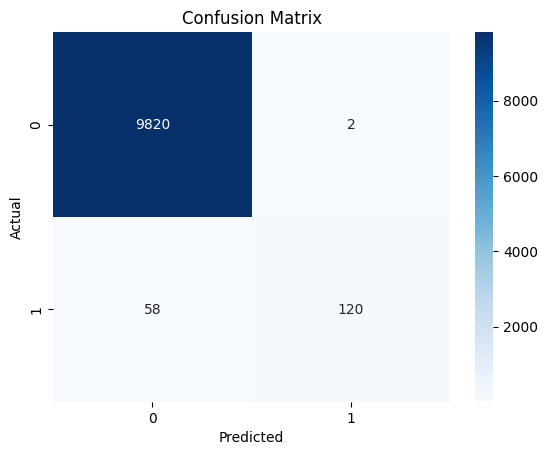

In [57]:
# lets instantiate the model
model = LogisticRegression(max_iter=1000)
# fit the model
model.fit(X_train, y_train)
# predict
y_pred = model.predict(X_test)
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [65]:
# lets see the precision, recall, f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)   
precision, recall, f1



# Task is to improve the model performance
# lets try with different models( KNN)
# different input features


(0.9836065573770492, 0.6741573033707865, 0.8)

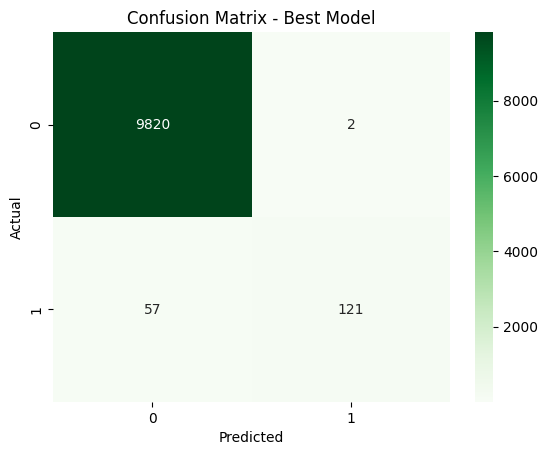

In [59]:
# grid search cv for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
# confusion matrix for best model
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()  

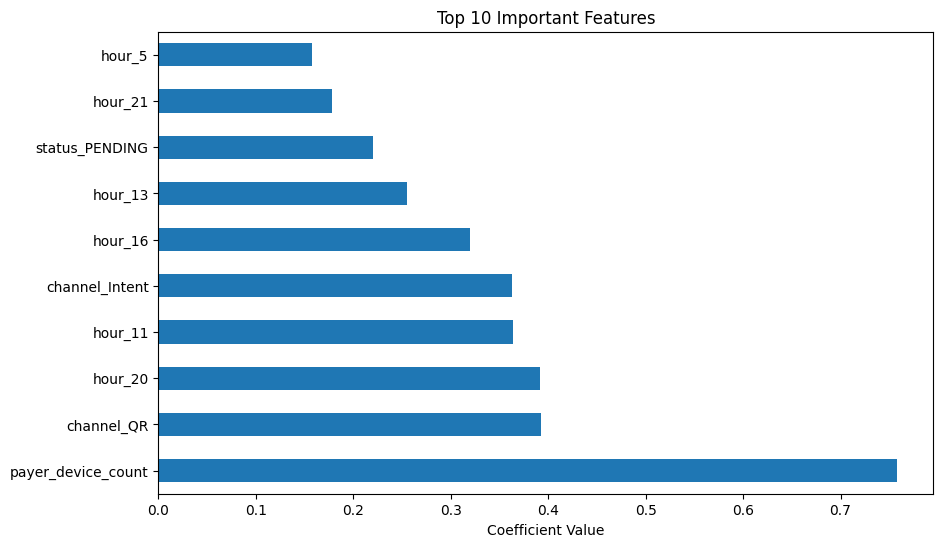

In [61]:
# lets see important features
feature_importance = pd.Series(best_model.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.xlabel('Coefficient Value')
plt.show()

In [62]:
#v save the model
import pickle
with open('fraud_detection_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [63]:
# lets create code for input feturization function
def featurize_input(input_data):
    input_data['timestamp'] = pd.to_datetime(input_data['timestamp'])
    input_data['hour'] = input_data['timestamp'].dt.hour
    input_data['day_of_week'] = input_data['timestamp'].dt.dayofweek
    input_data['month'] = input_data['timestamp'].dt.month
    input_data['log_amount'] = np.log1p(input_data['amount'])
    from geopy.distance import geodesic 
    def calculate_distance(row):
        payer_coords = (row['payer_lat'], row['payer_lon'])
        payee_coords = (row['payee_lat'], row['payee_lon'])
        return geodesic(payer_coords, payee_coords).km
    input_data['distance'] = input_data.apply(calculate_distance, axis=1)
    input_data['payer_device_count'] = input_data.groupby('payer_upi')['payer_device_id'].transform('nunique')
    input_data['payee_device_count'] = input_data.groupby('payee_upi')['payee_device_id'].transform('nunique')
    input_data = input_data.sort_values(by='timestamp')
    input_data['payer_txn_last_hour'] = (
        input_data.groupby('payer_upi')['timestamp']
        .transform(lambda x: x.diff().dt.total_seconds().lt(3600).cumsum())
    )
    input_data['payee_txn_last_hour'] = (
        input_data.groupby('payee_upi')['timestamp']
        .transform(lambda x: x.diff().dt.total_seconds().lt(3600).cumsum())
    )
    input_data = input_data.drop(columns=['txn_id', 'timestamp', 'payer_upi', 'payee_upi',
                                          'payer_device_id', 'payee_device_id', 'payer_city', 'payee_city',
                                          'payer_lat', 'payer_lon', 'payee_lat', 'payee_lon',
                                          'amount'])
    categorical_features = ['txn_type', 'channel', 'status',  'hour', 'day_of_week', 'month']
    input_data = pd.get_dummies(input_data, columns=categorical_features, drop_first=True)
    return input_data

In [64]:
# lets do the single prediction
# load the model
with open('fraud_detection_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
# sample input data
sample_input = pd.DataFrame([{
    'txn_id': 'TXN123456',
    'timestamp': '2023-10-01 14:30:00',
    'txn_type': 'payment',
    'channel': 'mobile',
    'amount': 1500.00,     
    'status': 'completed',
    'payer_upi': 'payer_001',
    'payee_upi': 'payee_001',
    'payer_device_id': 'device_001',
    'payee_device_id': 'device_002',
    'payer_city': 'CityA',
    'payee_city': 'CityB',
    'payer_lat': 12.9716,
    'payer_lon': 77.5946,
    'payee_lat': 13.0827,
    'payee_lon': 80.2707
}])
# featurize the input
featurized_input = featurize_input(sample_input)
# align the input features with training features
featurized_input = featurized_input.reindex(columns=X.columns, fill_value=0)
# predict
prediction = loaded_model.predict(featurized_input)
prediction_proba = loaded_model.predict_proba(featurized_input)[:, 1]
prediction, prediction_proba

(array([0]), array([0.00029275]))